# Predicting Final Grades with Discussion Forum Data

## Imports & Data

The data comes from Dr. Thad Starner's CS ???? OMSCS class. The class used the discussion forum Piazza, both to facilitate interaction between students and as a question-and-answer site. The goal of the below analysis is to analyze discussion forum participation and relate it to final grade outcomes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import nltk
import string
from nltk.sentiment import SentimentIntensityAnalyzer
import collections
from datetime import datetime

In [2]:
data = pd.read_excel("piazza data anonymized.xlsx", sheet_name = "in")

In [3]:
# convert the floats to numbers so the data doesn't break
data['submission'] = data["Submission HTML Removed_coding"].apply(str)

In [4]:
# rename columns
data = data.rename(columns={'Post Number': 'Post_Number', 'Created At': 'Created_At',
                            'CP Code': 'CP_Code', 'Part of Post': 'Part_of_Post', 'Subject_coding': 'Post_Title'})

## Cleaning data and adding features

### Removing stop words
We remove stop words that don't contribute to the meaning of the sentence, as well as puncuation. It would be beneficial to remove code as well, but that is difficult to accomplish because code can read like natural language.

In [5]:
# remove stop words, punctuation

stop_words = nltk.corpus.stopwords.words('english')
def preprocess(sentence):
    words = [w for w in sentence.lower().split() if w not in stop_words]
    return [w for w in words if (w not in string.punctuation and w not in "??==")]
            
data["Post_pp"] = data["submission"].apply(preprocess)

### Adding features
It would be nice to also know how much code is in each post, but that's beyond the scope of the NLP that we have available.

In [42]:
# length of post
data["Words_len"] = data["Post_pp"].str.len()

# sentiment analysis
data['sentiment'] = data["submission"].apply(nltk.sentiment.SentimentIntensityAnalyzer().polarity_scores)
data[['pos', 'neu', 'neg', 'compound']] = data['sentiment'].apply(pd.Series)

# time (discretized)
data['timestamp'] = data['Created_At'].apply(pd.Timestamp)

# day of the week of post
data['day_of_week'] = data['timestamp'].apply(datetime.weekday)

# CP offset by one - then we can take the sum of them so that 0's count but not too much
data['CP_Code_offset'] = data['CP_Code'] + 1

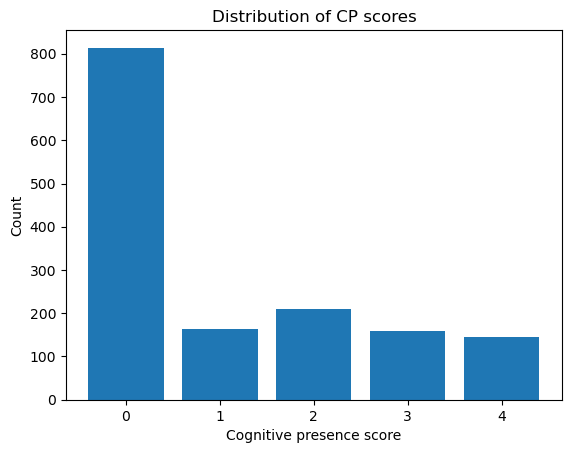

In [7]:
# distribution of cognitive presence
plt.bar(data.CP_Code.unique(), data.groupby('CP_Code').count()['Post_Number'])
plt.title("Distribution of CP scores")
plt.xlabel("Cognitive presence score")
plt.ylabel("Count")
plt.show()

# Cognitive presence scores are heavily skewed toward 0's.

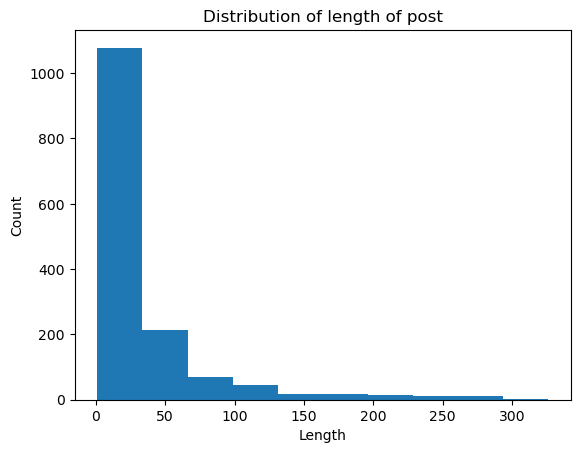

In [8]:
# distribution of lengths of post, removing some outliers
plt.hist(data['Words_len'].loc[data['Words_len'] < 400])
plt.title("Distribution of length of post")
plt.xlabel("Length")
plt.ylabel("Count")
plt.show()

# Most posts are very short, shorter than 50 words.

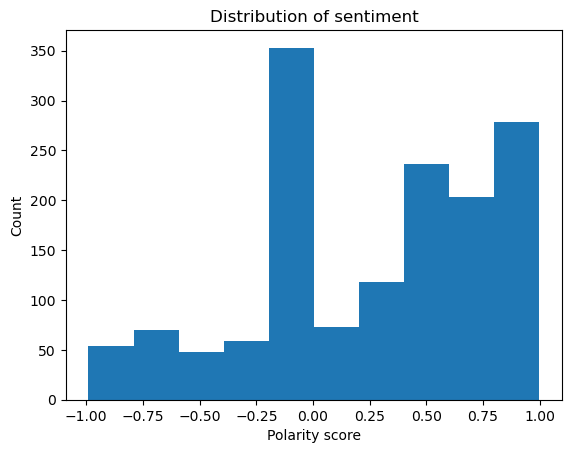

In [9]:
# distribution of sentiment
plt.hist(data['compound'])
plt.title("Distribution of sentiment")
plt.xlabel("Polarity score")
plt.ylabel("Count")
plt.show()

# -1 represents a negative sentiment, 0 a neutral sentiment, and 1 a positive sentiment. So most posts are right around 0.
# But there is a skew toward positive posts, which is good.
# The question remains, what kinds of posts are negative? Do the same students keep posting negative posts?

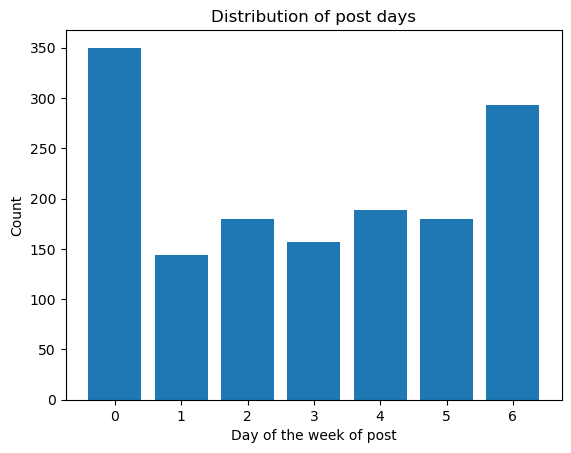

In [10]:
# distribution of day that the comment is posted
plt.bar(data.day_of_week.unique(), data.groupby('day_of_week').count()['Post_Number'])
plt.title("Distribution of post days")
plt.xlabel("Day of the week of post")
plt.ylabel("Count")
plt.show()

# We see that most posts are created on Saturday and Sunday. Perhaps this is when assignments are due,
# or maybe this is because there are no office hours on the weekends.

## Create post data

The code in this section aggregates the comments, follow-ups, and replies to a main post. Each "post" is a different thread, and we find stats about the size and cognitive presence of the post. The average sentiment of a megathread also represents the average sentiment toward an assignment.

In [11]:
posts_list = data.Post_Number.unique()

In [12]:
# number of replies for main posts, users, average CP code, starter
def get_post_stats(post_num):
    post_rows = data.loc[data['Post_Number'] == post_num]
    post_size = post_rows.shape[0]
    avg_CP = post_rows['CP_Code'].mean()
    avg_sentiment = post_rows['compound'].mean()
    
    #starter
    first_post_time = post_rows['Created_At'].min()
    first_post = post_rows[post_rows['Created_At'] == first_post_time]
    starter = first_post.iloc[0]['user_id_anonymized']
    title = first_post.iloc[0]['Post_Title']

    #number of unique commenters
    unique_commenters = len(post_rows.user_id_anonymized.unique())
    
#return [post_num, post_size, starter, avg_CP, unique_commenters, subposts]
    return [post_num, title, post_size, starter, avg_CP, avg_sentiment, unique_commenters]

In [43]:
post_stats = []
for post in posts_list:
    stats = get_post_stats(post)
    post_stats.append(stats)
#     post_stats.append(stats[:-1])
#     post_stats.extend(stats[-1])
posts = pd.DataFrame(post_stats, columns=["post_num", 'title','post_size', 'starter', 'average_CP', 
                                          'average_sentiment', 'unique_commenters'])

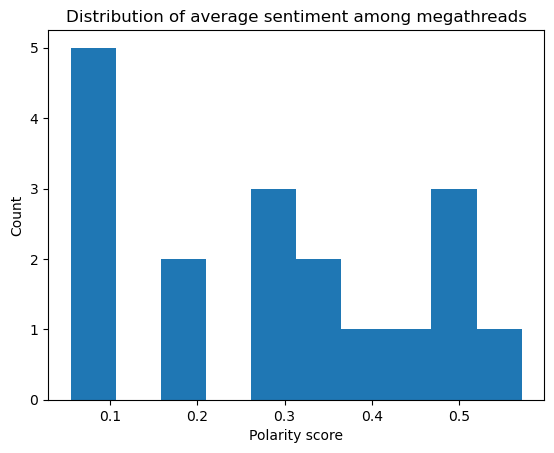

In [14]:
# question: do some assignments have a more negative sentiment than others?
# What does the distribution of sentiment across the megathreads look like?
megathreads = posts.loc[posts['post_size'] > 15]
plt.hist(megathreads['average_sentiment'])
plt.title("Distribution of average sentiment among megathreads")
plt.xlabel("Polarity score")
plt.ylabel("Count")
plt.show()

# We only have positive average sentiment across the entire megathread.
# But some threads are definitely better than others - the averages range from .1 to .5.

In [15]:
# Which assignments have the best/worst polarity score?
megathreads.sort_values(by=['average_sentiment'])

,post_num,title,post_size,starter,average_CP,average_sentiment,unique_commenters
45,1116,Assignment 4 - Part 1: Hand Tree &amp; Perform...,39,u00108,1.717949,0.055395,17
17,1192,Passing local k-fold but not on Gradescope,16,u0019,1.500000,0.064875,7
0,732,Assignment 4 - Part 0: Vectorization Discussion,28,u00139,0.000000,0.068746,14
44,1115,Assignment 4 - Part 0: Vectorization Discussion,19,u00108,1.157895,0.093484,10
90,810,Assignment 3 Part 1: Bayesian Network - Discus...,97,u0096,1.927835,0.094243,28
122,1163,Help with Assignment 3 Bonus,29,u00127,1.379310,0.168728,2
89,808,Assignment 3: Bonus - Discussion Thread,143,u0096,1.853147,0.181619,28
2,735,Assignment 4 - Part 3: Random Forests,50,u00139,0.840000,0.262548,23
18,1193,<NAME> someone cancel my gradescope submission...,17,u00164,0.000000,0.290841,5
1,733,Assignment 4 - Part 1: Hand Tree &amp; Perform...,54,u00139,0.333333,0.297307,23


In [36]:
megathreads.sort_values(by=['average_sentiment']).iloc[0]['title']

'Assignment 4 - Part 1: Hand Tree &amp; Performance Metrics'

In [17]:
# This section just counts the size of each post, it'll make the next part easier
def size_of_post(post_num):
    return posts.loc[posts['post_num'] == post_num].iloc[0]['post_size']

data['size_of_post'] = data['Post_Number'].apply(lambda x: posts.loc[posts['post_num'] == x].iloc[0]['post_size'])

## Create student data

This section aggreates the posts/comments by student.

In [18]:
parts_of_post = data.Part_of_Post.unique()

In [19]:
# number of posts, average length, sentiment, time

def get_user_stats(user_id):
    user_posts = data.loc[data['user_id_anonymized'] == user_id]
    num_posts = user_posts.shape[0]
    average_length = user_posts["Words_len"].mean()
    average_sentiment = user_posts['compound'].mean()
    mode_time = user_posts['day_of_week'].mode()[0]
    final_grades = user_posts['final_grades'].iloc[0]
    
    avg_cp = user_posts['CP_Code'].mean()
    cp_nonzero = user_posts.loc[user_posts['CP_Code'] > 0]
    avg_cp_nonzero = cp_nonzero['CP_Code'].mean() if cp_nonzero.shape[0] > 0 else 0
    sum_offset_CP = user_posts['CP_Code_offset'].sum()
    avg_offset_CP = user_posts['CP_Code_offset'].mean()
    sqrt_offset_CP = np.sqrt(user_posts['CP_Code_offset']).sum()
    sqrt_offset_CP_2 = user_posts['CP_Code_offset'].sum() ** (1/2)
    
    posts_created = posts.loc[posts['starter'] == user_id]
    num_posts_created = posts_created.shape[0]
    
    part_count = [user_posts.loc[user_posts['Part_of_Post'] == part].shape[0] for part in parts_of_post]
    
    # count the number of likely true questions
    questions = user_posts.loc[user_posts['Part_of_Post'] == 'started_off_question'].shape[0]
    questions += user_posts.loc[(user_posts['Part_of_Post'] == 'followup') & (user_posts['size_of_post'] > 15)].shape[0]
    
    # count the number of likely true answers
    answers = user_posts.loc[user_posts['Part_of_Post'] == 'started_off_s_answer'].shape[0]
    answers += user_posts.loc[user_posts['Part_of_Post'] == 'started_off_i_answer'].shape[0]
    
    cols = [user_id, num_posts, average_length, average_sentiment, mode_time, final_grades, avg_cp, 
            avg_cp_nonzero, sum_offset_CP, avg_offset_CP, num_posts_created, sqrt_offset_CP, sqrt_offset_CP_2, 
            questions, answers]
    cols.extend(part_count)
    return cols
    
    #print(str(num_posts), str(average_length), "hi", str(average_sentiment), "hi", str(mode_time))

In [20]:
users_list = data.user_id_anonymized.unique()
user_stats = []
for user in users_list:
    user_stats.append(get_user_stats(user))
cols = ['user_id', 'num_posts', 'avg_length', 'avg_sentiment', 'mode_day', 'final_grade', 'avg_cp', 
        'avg_cp_nonzero', 'sum_offset_CP', 'avg_offset_CP', 'num_posts_created', 'offset_sqrt', 'offset_sqrt_2',
       'questions', 'answers']
cols.extend(parts_of_post)
users = pd.DataFrame(user_stats, columns=cols)

In [21]:
# seperate students and instructors for analysis

# Actually, this is a pretty big problem because some of the posts labeled as student contributions update the TA answer,
# and some of the posts with final grades are labeled as TA contributions
instructor_ids = data.loc[(data['user_role'] == 'TA')].user_id_anonymized.unique()
instructor_ids = np.append(instructor_ids, ['u00160'])

instructors = users.loc[users.user_id.isin(instructor_ids)]
students =  users.loc[~users.user_id.isin(instructor_ids)]

In [22]:
instructor_ids

array(['u00139', 'u00108', 'u006', 'u00177', 'u0024', 'u00103', 'u00162',
       'u0096', 'u0010', 'u007', 'u00122', 'u0018', 'u0080', 'u00160'],
      dtype=object)

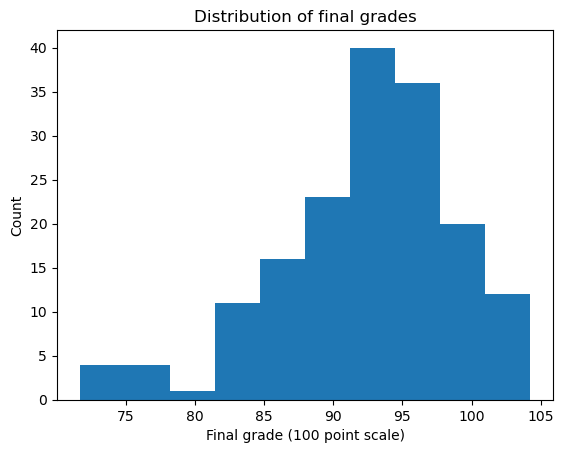

92.35035628742517

In [23]:
plt.hist(students['final_grade'])
plt.title("Distribution of final grades")
plt.xlabel("Final grade (100 point scale)")
plt.ylabel("Count")
plt.show()

students['final_grade'].mean()
# No one who posted on the forum did worse than a 70. The mean grade of participating students is 92.3.

## Results

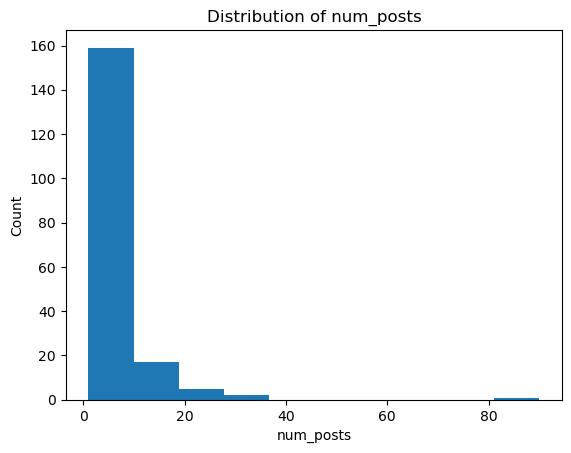

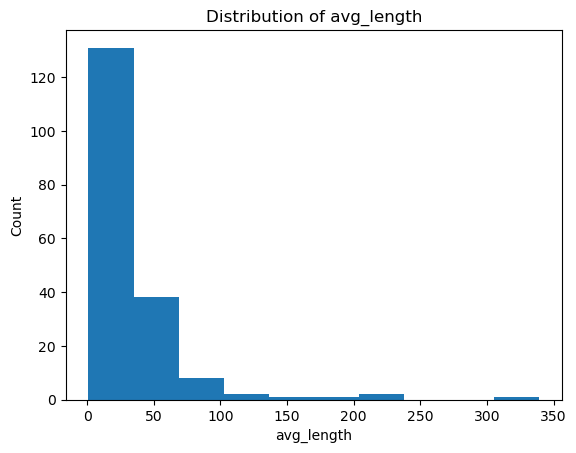

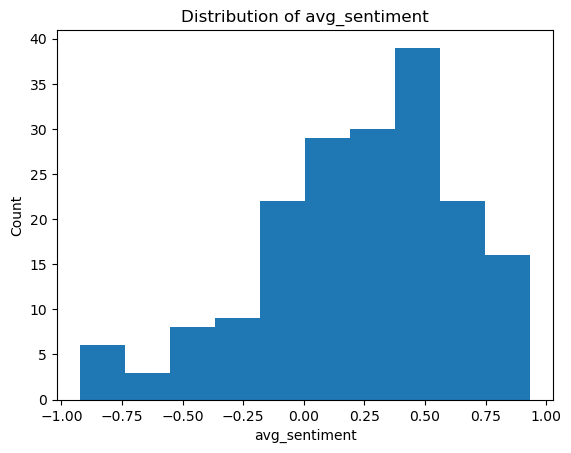

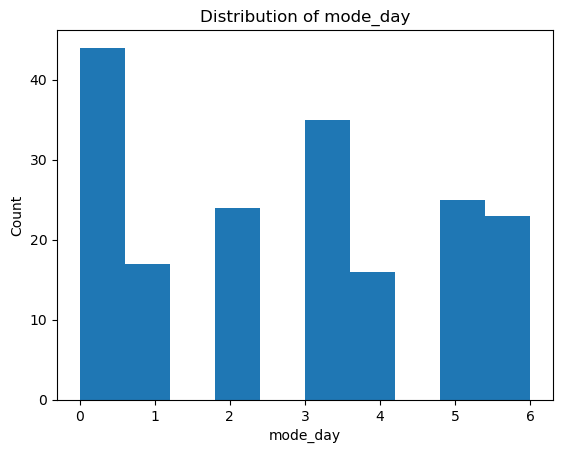

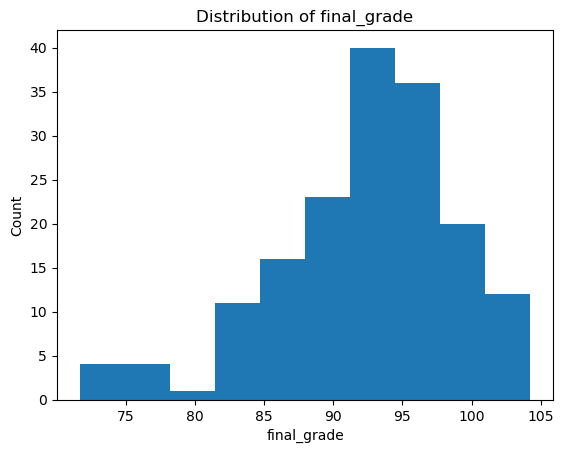

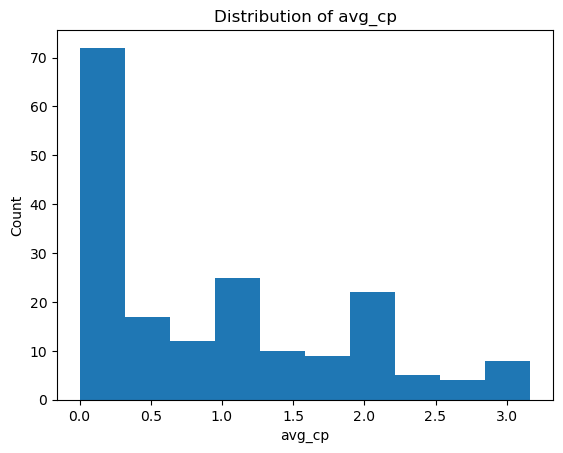

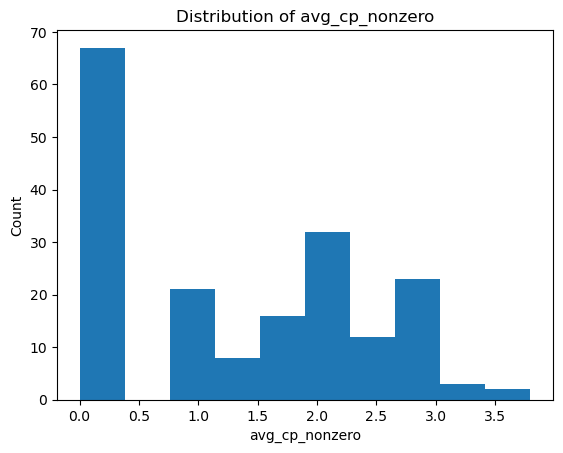

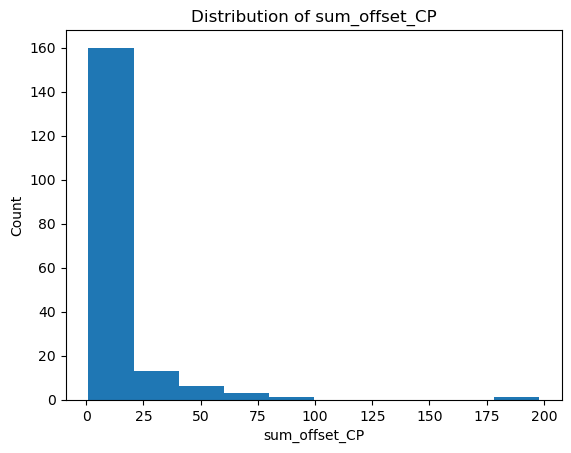

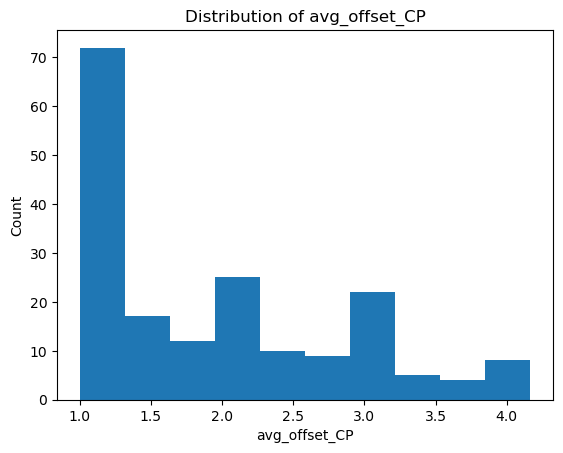

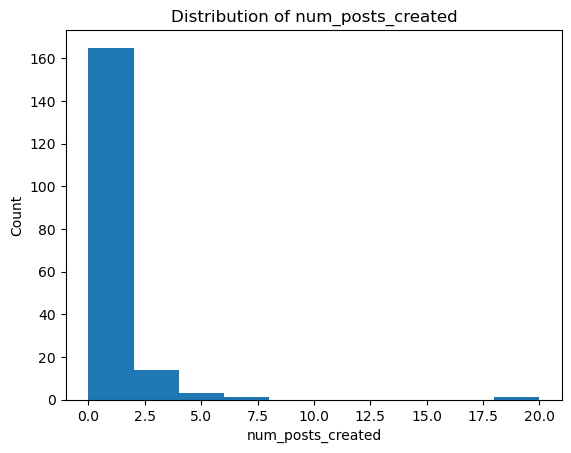

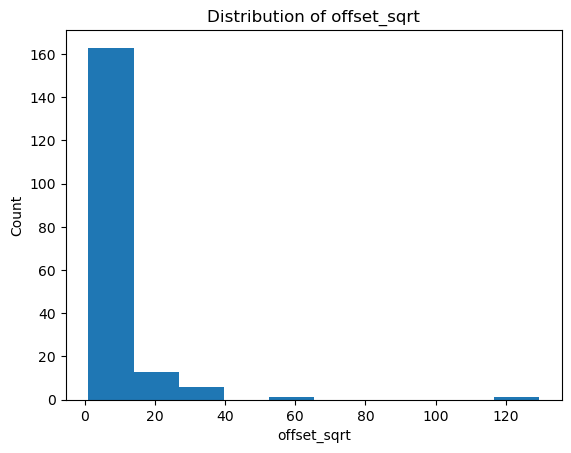

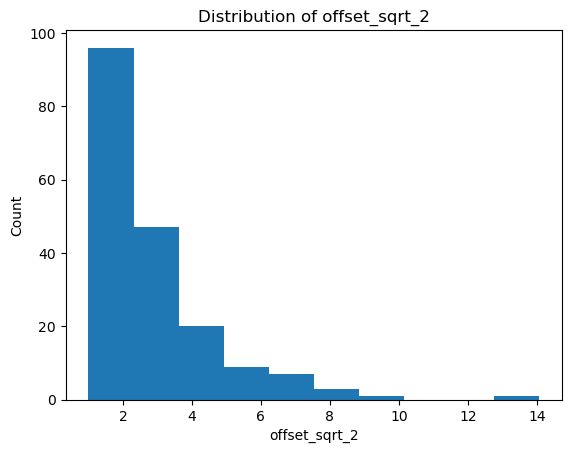

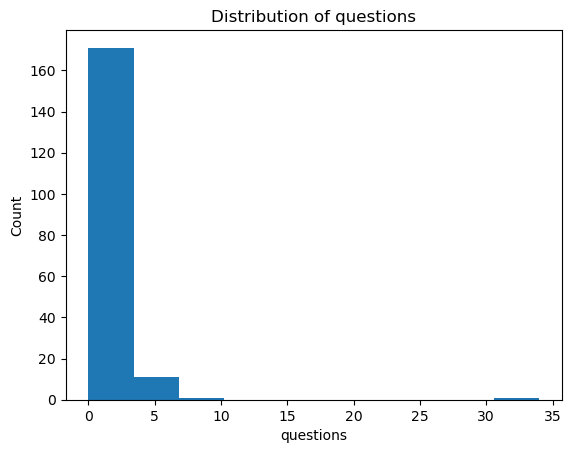

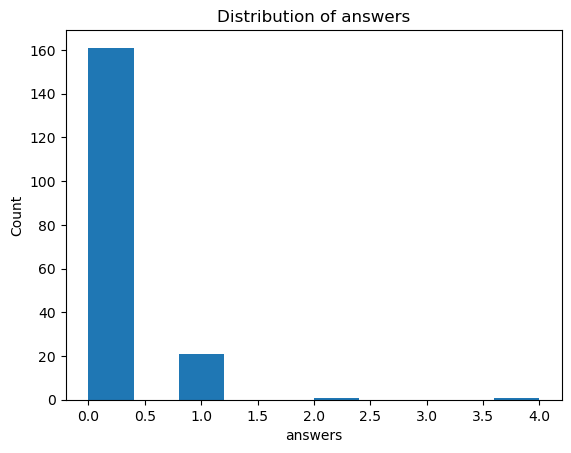

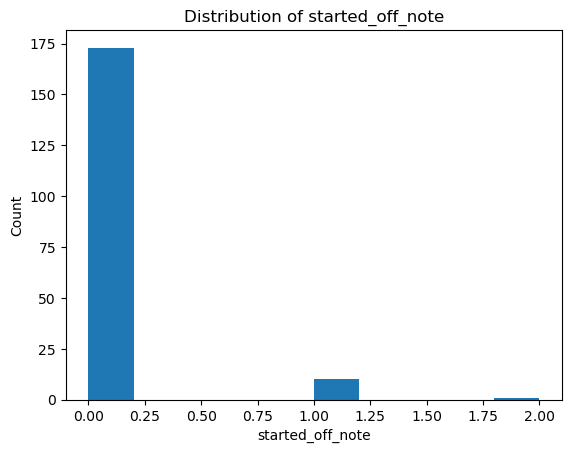

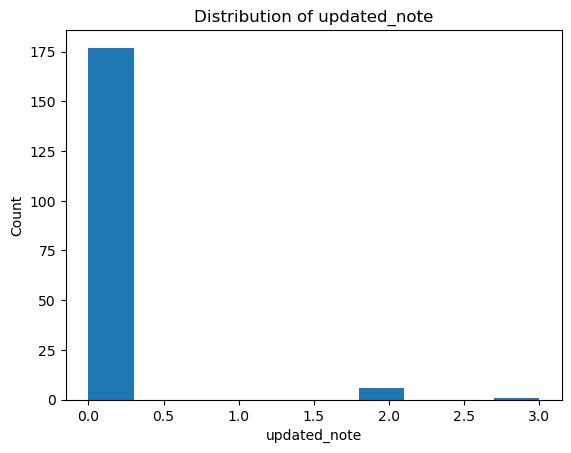

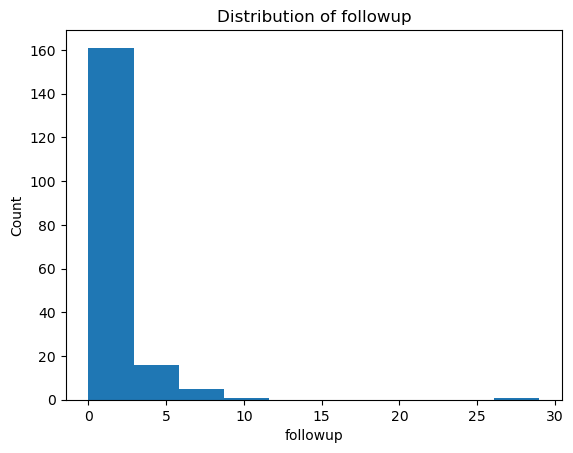

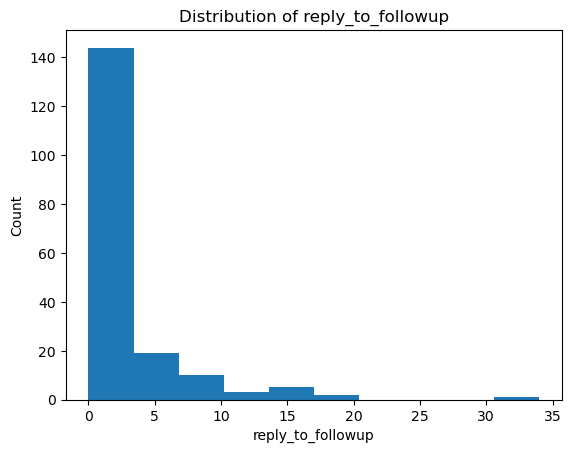

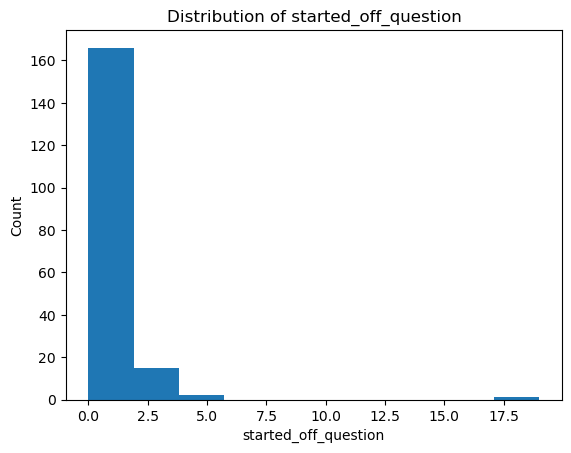

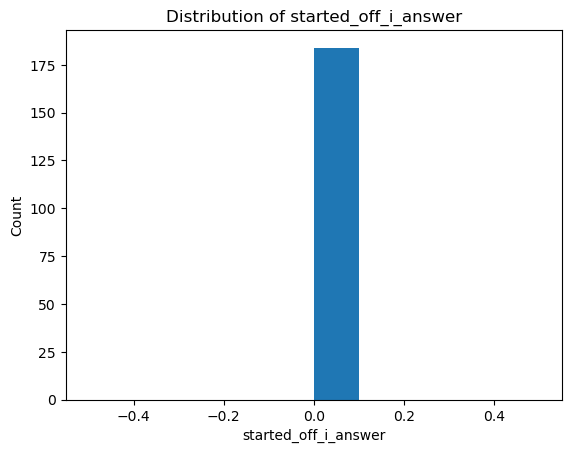

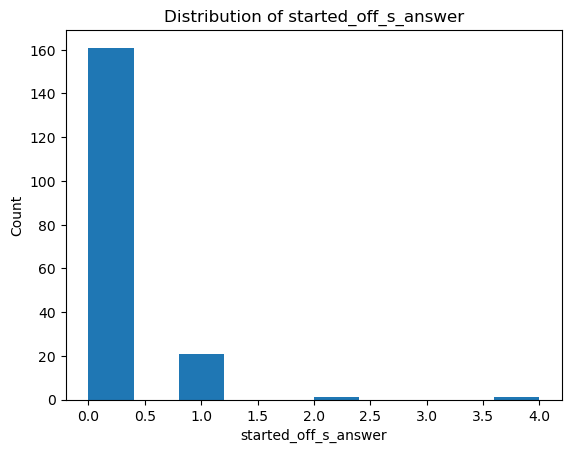

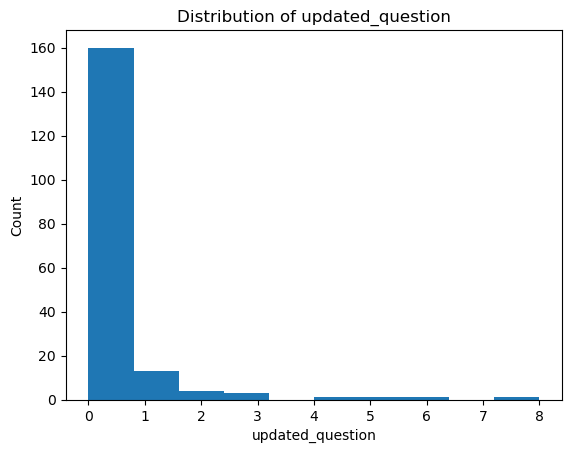

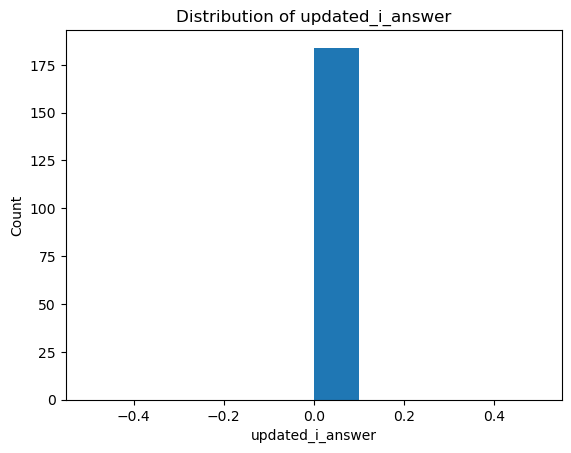

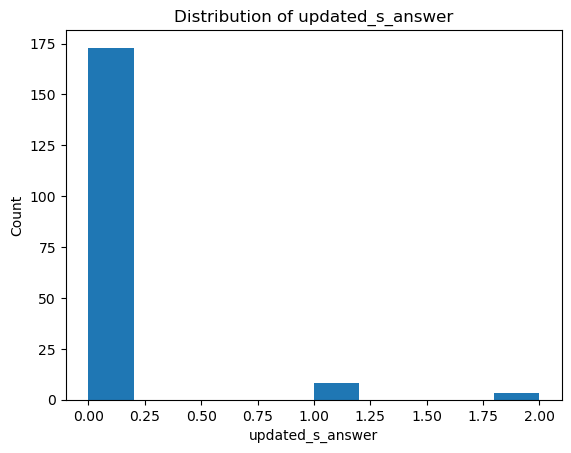

In [24]:
# distribution of all the metrics
students_no_id = students[students.columns[1:]]
#fig, ax = plt.subplots(int(students.shape[1]))
for i, (col_name, col) in enumerate(students_no_id.iteritems()):
    plt.hist(col)
    plt.title("Distribution of " + str(col_name))
    plt.xlabel(col_name)
    plt.ylabel("Count")
    plt.show()
    
# At a glance, these distributions look overall similar to the ones across posts in general, without stratifying by student.
# Actually, we have a problem because there should be no instructor updates among the students

In [25]:
# correlation matrix
students.corr()

,num_posts,avg_length,avg_sentiment,mode_day,final_grade,avg_cp,avg_cp_nonzero,sum_offset_CP,avg_offset_CP,num_posts_created,...,started_off_note,updated_note,followup,reply_to_followup,started_off_question,started_off_i_answer,started_off_s_answer,updated_question,updated_i_answer,updated_s_answer
num_posts,1.000000,0.146209,0.046720,0.093537,0.199450,0.111581,0.254333,0.969267,0.111581,0.820594,...,0.436153,0.427332,0.889422,0.886951,0.794163,NaN,0.561870,0.311640,NaN,0.060988
avg_length,0.146209,1.000000,0.128303,0.129107,-0.006853,0.272758,0.247195,0.206055,0.272758,0.168017,...,0.278389,0.222496,0.033842,0.053122,0.112607,NaN,0.177513,0.469903,NaN,-0.022499
avg_sentiment,0.046720,0.128303,1.000000,0.053599,-0.116414,-0.116109,-0.058219,0.035251,-0.116109,0.054083,...,-0.040392,0.050525,0.012762,0.030508,0.068412,NaN,0.061376,0.065952,NaN,0.024490
mode_day,0.093537,0.129107,0.053599,1.000000,-0.006548,0.029682,0.013228,0.101288,0.029682,0.011753,...,0.064276,0.166670,0.052822,0.102793,0.008178,NaN,0.006241,0.086428,NaN,0.009659
final_grade,0.199450,-0.006853,-0.116414,-0.006548,1.000000,0.128363,0.164195,0.210734,0.128363,-0.043345,...,-0.014482,-0.023810,0.058853,0.279190,-0.061045,NaN,-0.034414,0.011575,NaN,0.030856
avg_cp,0.111581,0.272758,-0.116109,0.029682,0.128363,1.000000,0.837381,0.276486,1.000000,-0.005866,...,0.079947,0.070234,0.025149,0.160567,-0.030272,NaN,0.092113,0.086348,NaN,0.096253
avg_cp_nonzero,0.254333,0.247195,-0.058219,0.013228,0.164195,0.837381,1.000000,0.365727,0.837381,0.045863,...,0.077244,0.058244,0.140895,0.345165,0.026359,NaN,0.100182,0.089888,NaN,0.072585
sum_offset_CP,0.969267,0.206055,0.035251,0.101288,0.210734,0.276486,0.365727,1.000000,0.276486,0.759425,...,0.452781,0.423941,0.828006,0.883306,0.721663,NaN,0.547435,0.338169,NaN,0.095325
avg_offset_CP,0.111581,0.272758,-0.116109,0.029682,0.128363,1.000000,0.837381,0.276486,1.000000,-0.005866,...,0.079947,0.070234,0.025149,0.160567,-0.030272,NaN,0.092113,0.086348,NaN,0.096253
num_posts_created,0.820594,0.168017,0.054083,0.011753,-0.043345,-0.005866,0.045863,0.759425,-0.005866,1.000000,...,0.465997,0.475517,0.819116,0.520027,0.979796,NaN,0.597890,0.291699,NaN,-0.043260


In [26]:
# The average value for each metric split according to final grade.
students.groupby(pd.cut(students['final_grade'], np.arange(70, 110, 5))).mean()

# Number of posts steadily increases with grade bracket.

,num_posts,avg_length,avg_sentiment,mode_day,final_grade,avg_cp,avg_cp_nonzero,sum_offset_CP,avg_offset_CP,num_posts_created,...,started_off_note,updated_note,followup,reply_to_followup,started_off_question,started_off_i_answer,started_off_s_answer,updated_question,updated_i_answer,updated_s_answer
final_grade,,,,,,,,,,,,,,,,,,,,,
"(70, 75]",1.000000,53.000000,0.686200,1.500000,73.610000,0.750000,0.750000,1.750000,1.750000,0.250000,...,0.000000,0.000000,0.500000,0.250000,0.250000,0.0,0.000000,0.000000,0.0,0.000000
"(75, 80]",1.400000,15.700000,0.337320,2.400000,77.528700,0.400000,0.400000,1.800000,1.400000,0.200000,...,0.000000,0.000000,0.800000,0.400000,0.200000,0.0,0.000000,0.000000,0.0,0.000000
"(80, 85]",4.615385,39.741667,0.165093,3.076923,83.256538,0.910897,1.337179,9.153846,1.910897,0.923077,...,0.153846,0.153846,1.769231,1.384615,0.846154,0.0,0.153846,0.153846,0.0,0.000000
"(85, 90]",4.571429,35.744526,0.226236,2.785714,87.884357,0.862014,1.292857,8.142857,1.862014,0.750000,...,0.071429,0.107143,1.392857,1.678571,0.678571,0.0,0.178571,0.392857,0.0,0.071429
"(90, 95]",4.907407,27.900779,0.247433,2.796296,92.661565,0.766312,1.203674,9.740741,1.766312,0.611111,...,0.055556,0.074074,1.407407,2.259259,0.592593,0.0,0.148148,0.240741,0.0,0.129630
"(95, 100]",5.085106,33.973060,0.275196,2.446809,97.150904,0.941075,1.338790,10.468085,1.941075,0.595745,...,0.063830,0.042553,1.361702,2.659574,0.531915,0.0,0.106383,0.255319,0.0,0.063830
"(100, 105]",7.750000,38.796092,0.005643,2.500000,101.719500,1.333075,1.868028,18.062500,2.333075,0.375000,...,0.000000,0.000000,1.750000,5.437500,0.375000,0.0,0.000000,0.187500,0.0,0.000000


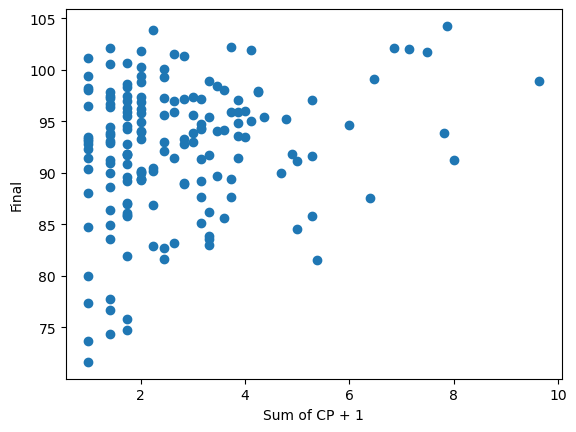

In [27]:
# The metric that correlates with final grades most is this "offset_CP".
# Summing the offset CP as opposed to the actual CP allows us to give some credit to the 0 posts.
# Likewise, it's better than using the average, because the number of posts should matter.
# High-frequency posters will also have a lot of 0 posts, so this will bring down their averages.

plt.scatter(np.sqrt(students['sum_offset_CP']), students['final_grade'])
plt.xlabel('Sum of CP + 1')
plt.ylabel('Final')
plt.show()

In [28]:
data.groupby('Part_of_Post').mean()

,Post_Number,CP_Code,final_grades,Words_len,pos,neu,neg,compound,day_of_week,CP_Code_offset,size_of_post
Part_of_Post,,,,,,,,,,,
followup,1157.185535,0.858491,92.881521,30.823899,0.051500,0.838613,0.109903,0.188021,2.732704,1.858491,40.276730
reply_to_followup,1132.725352,1.249296,95.923471,18.814085,0.033497,0.788331,0.178176,0.275157,2.914085,2.249296,49.445070
started_off_i_answer,1225.622807,1.578947,101.380529,16.131579,0.025386,0.820342,0.154272,0.237982,2.649123,2.578947,6.017544
started_off_note,1171.233333,0.600000,96.519444,90.500000,0.025133,0.838367,0.136400,0.335563,1.900000,1.600000,24.833333
started_off_question,1238.622047,0.811024,91.813032,64.637795,0.060921,0.833307,0.105772,0.272418,2.574803,1.811024,6.094488
started_off_s_answer,1293.444444,1.185185,91.716300,14.592593,0.043963,0.816111,0.140000,0.189574,2.185185,2.185185,7.074074
updated_i_answer,1336.333333,2.000000,87.637000,33.000000,0.041833,0.812167,0.146167,0.429433,2.166667,3.000000,6.833333
updated_note,1056.109890,0.571429,95.582200,121.835165,0.015022,0.841923,0.143110,0.665708,1.549451,1.571429,17.912088
updated_question,1327.321429,1.142857,92.635146,201.678571,0.045214,0.862625,0.092107,0.383334,2.982143,2.142857,7.696429


In [29]:
len(students.user_id.unique())
len(posts.post_num.unique())

155

**Problems with our data set**

No one who posted on the discussion forum failed the class.
Some students don't have final grades.
Some instructors have final grades.

## Metrics that might go on the dashboard
There are also some scattered through the notebook. I commented these out so that individual post content would not be posted to GitHub, for privacy reasons.

In [44]:
# top student answerers
#students.sort_values(by=['answers'], ascending=False)

In [45]:
# top student question-askers
#students.sort_values(by=['questions'], ascending=False)

In [46]:
# top instructor contributers/answerers
#instructors.sort_values(by=['answers'], ascending=False)

In [33]:
students.to_csv('students.csv')
instructors.to_csv('instructors.csv')
posts.to_csv('posts.csv')